### Enable importing modules from the parent project directory
 --> (e.g., for running this script from subfolders like /scripts or /notebooks)

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [2]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [3]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [4]:

mountain_df = pd.read_csv("D:\\Thesis\\Project\\Data\\mountain_data.csv")

# Counting the different types of missingness in the dataset
stats = {
    "Total Rows": len(mountain_df),
    "Total Columns": len(mountain_df.columns),
    "Zero Values": (mountain_df == 0).sum().sum(),
    "NaN Values": mountain_df.isna().sum().sum(),
    "Blank Strings": (mountain_df == "").sum().sum(),
    "Unknown Strings": (mountain_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,2785482
1,Total Columns,6
2,Zero Values,96350
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [5]:
mountain_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,45200SF,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-2.1
1,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-0.8
2,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-2.2
3,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-0.6
4,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-1.0


### Displaying column-wise metadata

##### Includes:
- Total number of entries
- Column names and types
- Non-null counts
- Memory usage

In [6]:
mountain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785482 entries, 0 to 2785481
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 127.5+ MB


### describe() provide us with statistical summary of numeric columns
#### Includes:
- Count, mean, std deviation
- Min, 25%, 50%, 75%, and max values

In [7]:
mountain_df.describe()

,value
count,2.785482e+06
mean,5.304164e+01
std,8.350127e+01
min,-2.460000e+01
25%,1.200000e+00
50%,8.200000e+00
75%,7.700000e+01
max,3.660000e+02


In [8]:
# Preview data
print("🔍 Shape:", mountain_df.shape)

🔍 Shape: (2785482, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", mountain_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [10]:
unique_values = mountain_df['sensor_code'].unique()
unique_values

array(['LT', 'WR', 'WG', 'WG.BOE', 'LF', 'HS', 'N'], dtype=object)

### checking unique similar station_codes

In [11]:
unique_values1 = mountain_df['station_code'].unique()
unique_values1

array(['45200SF', '82500WS', '45100WS', '00700WS', '00390SF', '06040WS',
       '06090SF', '35100WS', '50400WS', '50360SF', '61690SF', '61720WS',
       '20720WS', '20690SF', '91210WS', '91180SF', '24300SF', '78480SF',
       '15000SF', '34200WS', '31810SF', '66000WS', '66100SF', '80100SF',
       '90005SF', '15050WS', '07740WS', '15590SF', '01080SF', '20050SF',
       '35205SF', '24170WS', '53200SF', '42830SF', '62270SF', '02700SF'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [12]:
unique_values2 = mountain_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Altezza neve al suolo', 'Precipitazioni'], dtype=object)

### checking unit of data values

In [13]:
unique_values3 = mountain_df['unit'].unique()
unique_values3

array(['°C', '° ', 'm/s', '%', 'cm', 'mm'], dtype=object)

### looking at unique values

In [14]:
unique_values4 = mountain_df['value'].unique()
unique_values4

array([ -2.1,  -0.8,  -2.2, ..., 327.3, 366. , 365. ], shape=(3847,))

### Checking the columns i have and how they pronounced

In [15]:
column_names = list(mountain_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [16]:
zero_counts = (mountain_df == 0).sum()
print(zero_counts)

station_code          0
sensor_code           0
description_it        0
unit                  0
timestamp             0
value             96350
dtype: int64


### displaying the values with zeroes

In [17]:
mountain_df[mountain_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
38,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 05:00:00,0.0
57,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 19:30:00,0.0
93,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 01:30:00,0.0
247,45200SF,LT,Temperatura dell´aria,°C,2024-12-26 20:30:00,0.0
1403,45200SF,LT,Temperatura dell´aria,°C,2024-12-02 18:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [18]:
# Make sure 'value' is numeric
mountain_df['value'] = pd.to_numeric(mountain_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    mountain_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0           N           3165        3085        97.472354
1          WG         485833       45854         9.438223
2      WG.BOE         485834       37041         7.624209
3          WR         486667        5332         1.095616
4          LT         502908        3974         0.790204
5          HS         318145        1064         0.334439
6          LF         502930           0         0.000000


In [19]:
mountain_df.isnull().sum()

station_code      0
sensor_code       0
description_it    0
unit              0
timestamp         0
value             0
dtype: int64

In [20]:
print(mountain_df.columns.tolist())


['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']


In [21]:
mountain_df[(mountain_df["sensor_code"] == "LT")]["value"].isnull().sum()

np.int64(0)

In [22]:
mountain_df[(mountain_df["sensor_code"] == "LT")]["value"].value_counts().head()


value
 0.0    3974
-1.9    3963
-2.3    3917
-2.9    3898
-2.4    3890
Name: count, dtype: int64

In [23]:
# Step 1: Select sensor `LF`
lt_df = mountain_df[mountain_df['sensor_code'] == 'LT'].copy()

In [24]:
# Step 2: Replace `0.0` values with NaN
#lt_df.loc[lt_df['value'] == 0.0, 'value'] = np.nan

In [25]:
# Step 3: Pivot to wide format (timestamp × station_code)
lt_df['timestamp'] = pd.to_datetime(lt_df['timestamp'])
pivot_df = lt_df.pivot(index='timestamp', columns='station_code', values='value')

In [26]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [27]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [28]:
clean_df

station_code,00390SF,00700WS,01080SF,02700SF,06090SF,07740WS,15000SF,15590SF,20050SF,20690SF,...,61720WS,62270SF,66000WS,66100SF,78480SF,80100SF,82500WS,90005SF,91180SF,91210WS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,-1.8,-1.0,2.9,1.6,2.6,0.5,0.0,-1.0,-2.3,-1.2,...,0.4,0.5,0.3,-1.3,1.0,-1.1,-0.8,-2.0,1.2,-1.1
2023-01-01 00:30:00,-2.2,-0.1,2.3,0.5,1.7,1.2,0.0,-1.0,-2.8,-1.7,...,1.7,0.7,0.2,-0.9,1.4,-1.0,-0.8,-1.4,-1.3,-0.9
2023-01-01 01:00:00,-1.8,-0.6,3.2,1.7,2.4,0.4,0.3,-1.0,-2.5,-1.5,...,2.1,1.1,0.0,-0.9,1.7,-0.9,-0.8,-1.4,-1.4,-0.1
2023-01-01 01:30:00,-2.5,0.6,3.0,2.8,1.7,0.6,0.8,-1.2,-3.3,-1.6,...,2.2,0.6,-0.2,-0.8,0.7,-0.8,-0.8,-1.3,-1.2,0.2
2023-01-01 02:00:00,-2.9,-0.8,2.4,2.1,2.0,0.9,0.1,-1.4,-3.1,-1.3,...,1.9,0.3,-0.6,-0.8,0.8,-0.7,-0.7,-0.8,-0.9,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-4.6,-3.7,-1.5,-3.9,-3.6,-0.4,-6.3,-0.8,-2.1,0.4,...,-2.5,-0.4,-1.7,0.6,0.0,-2.2,0.0,-1.9,0.3,-3.3
2024-12-31 22:30:00,-5.2,-3.6,-1.6,-3.2,-3.6,-0.5,-6.5,-1.0,-2.9,0.2,...,-3.1,-0.4,-1.6,0.8,0.1,-1.7,0.0,-0.8,0.0,-3.8
2024-12-31 23:00:00,-4.9,-3.7,-1.7,-3.7,-3.0,-0.5,-5.7,-1.1,-4.0,0.0,...,-3.0,-0.3,-1.9,0.2,-0.1,-1.8,0.0,-1.5,-0.2,-3.8


In [29]:
# Step 6: Pick a target station 
target_station = clean_df.columns[2]

#### displaying target station

In [30]:
target_station

'01080SF'

In [31]:
# Step 7: Computing Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [32]:
correlations

station_code
07740WS    0.963428
15000SF    0.963066
66000WS    0.954931
42830SF    0.952816
00700WS    0.952574
02700SF    0.951485
20720WS    0.950659
62270SF    0.949221
06090SF    0.947076
24170WS    0.946432
91210WS    0.944073
61720WS    0.943638
45100WS    0.941387
34200WS    0.936710
66100SF    0.931119
53200SF    0.931114
31810SF    0.930363
82500WS    0.927434
78480SF    0.925450
35205SF    0.922040
61690SF    0.919933
35100WS    0.919530
80100SF    0.918944
45200SF    0.909692
91180SF    0.904420
20690SF    0.901905
20050SF    0.899161
90005SF    0.896624
15590SF    0.890313
00390SF    0.888495
50360SF    0.872446
24300SF    0.853997
Name: 01080SF, dtype: float64

In [33]:

# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [34]:
top_refs

['07740WS', '15000SF']

#### Checking the final dataframe

In [35]:
final_df

station_code,01080SF,07740WS,15000SF
timestamp,,,
2023-01-01 00:00:00,2.9,0.5,0.0
2023-01-01 00:30:00,2.3,1.2,0.0
2023-01-01 01:00:00,3.2,0.4,0.3
2023-01-01 01:30:00,3.0,0.6,0.8
2023-01-01 02:00:00,2.4,0.9,0.1
...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3
2024-12-31 22:30:00,-1.6,-0.5,-6.5
2024-12-31 23:00:00,-1.7,-0.5,-5.7


In [36]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [37]:
pattern_df

station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,2.9,0.5,0.0,0.3
2023-01-01 00:30:00,2.3,1.2,0.0,0.2
2023-01-01 01:00:00,3.2,0.4,0.3,0.0
2023-01-01 01:30:00,3.0,0.6,0.8,-0.2
2023-01-01 02:00:00,2.4,0.9,0.1,-0.6
...,...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3,-1.7
2024-12-31 22:30:00,-1.6,-0.5,-6.5,-1.6
2024-12-31 23:00:00,-1.7,-0.5,-5.7,-1.9


In [38]:
pattern_df.isnull().sum()

station_code
01080SF    1
07740WS    1
15000SF    1
66000WS    1
dtype: int64

In [39]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 01080SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 01080SF, dtype: float64

🔍 Missing value in station 07740WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 07740WS, dtype: float64

🔍 Missing value in station 15000SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 15000SF, dtype: float64

🔍 Missing value in station 66000WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 66000WS, dtype: float64


In [40]:
pattern_df = pattern_df.drop(index="2023-02-14 14:30:00")

In [41]:
pattern_df.isnull().sum()

station_code
01080SF    0
07740WS    0
15000SF    0
66000WS    0
dtype: int64

In [42]:
(pattern_df == "unknown").sum()
(pattern_df == "UNK").sum()
(pattern_df == "missing").sum()
(pattern_df == "").sum()


station_code
01080SF    0
07740WS    0
15000SF    0
66000WS    0
dtype: int64

In [43]:
(pattern_df == 0).sum()

station_code
01080SF    98
07740WS    85
15000SF    80
66000WS    90
dtype: int64

In [44]:
def count_nan_blocks(series):
    is_nan = series.isna().astype(int)
    block_lengths = (is_nan.diff(1) != 0).cumsum()
    blocks = is_nan.groupby(block_lengths).sum()
    return blocks[blocks > 0].values  # lengths of NaN blocks

for col in pattern_df.columns:
    print(f"\n🔍 Station {col}")
    block_lengths = count_nan_blocks(pattern_df[col])
    print("  Missing block lengths:", block_lengths)
    print("  # Blocks:", len(block_lengths))
    print("  Max block length:", block_lengths.max() if len(block_lengths) > 0 else 0)



🔍 Station 01080SF
  Missing block lengths: []
  # Blocks: 0
  Max block length: 0

🔍 Station 07740WS
  Missing block lengths: []
  # Blocks: 0
  Max block length: 0

🔍 Station 15000SF
  Missing block lengths: []
  # Blocks: 0
  Max block length: 0

🔍 Station 66000WS
  Missing block lengths: []
  # Blocks: 0
  Max block length: 0


In [45]:
print(pattern_df.columns.tolist())


['01080SF', '07740WS', '15000SF', '66000WS']


#### Plotting target station with reference stations

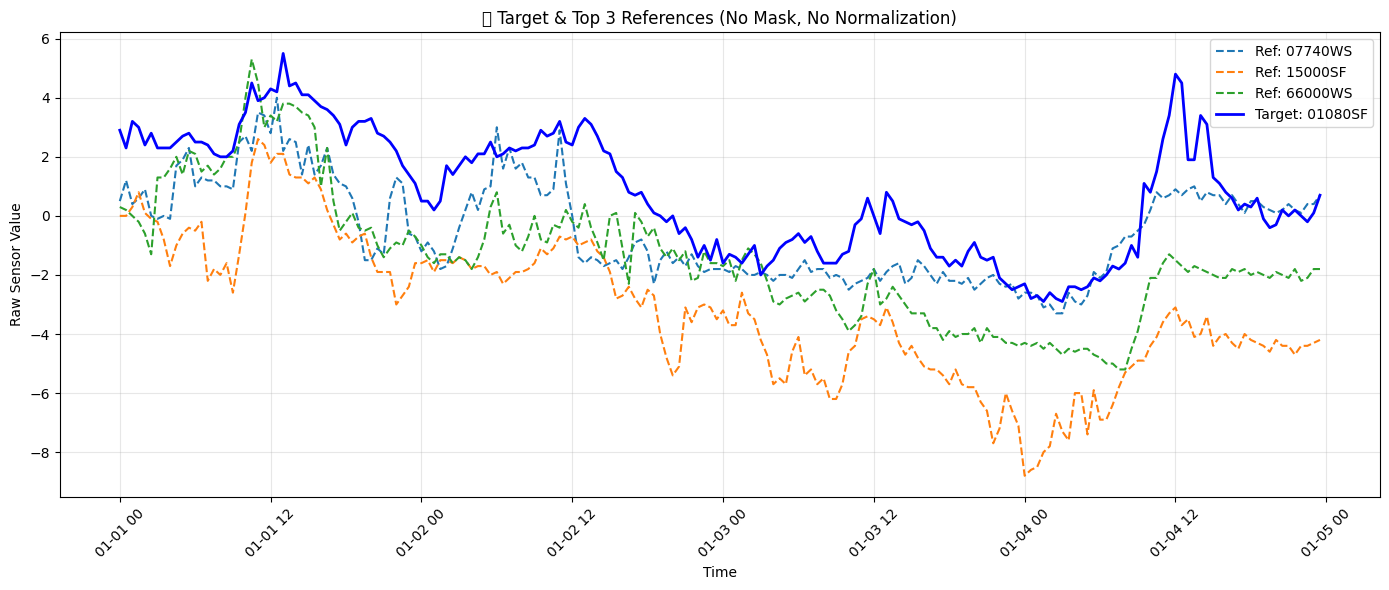

In [46]:
# Define the stations 
target = "01080SF"  # Target station
# References are the top 3 correlated stations
references = ["07740WS","15000SF","66000WS"]

# Defining time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slicing the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plotting the reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plotting the target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [47]:
from sklearn.preprocessing import StandardScaler

#  Initialize the Scaler
scaler = StandardScaler()

#  Fitting the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

#  Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

#  Print shape and preview
print(" Normalized shape:", normalized_df.shape)
display(normalized_df.head())


 Normalized shape: (14591, 4)


station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,1.097980,0.695222,1.401801,1.052163
2023-01-01 00:30:00,0.978235,0.833345,1.401801,1.032494
2023-01-01 01:00:00,1.157852,0.675490,1.461425,0.993156
2023-01-01 01:30:00,1.117937,0.714954,1.560798,0.953818
2023-01-01 02:00:00,0.998193,0.774149,1.421676,0.875143


-> What This Does:
- Performs z-score normalization: subtracts the mean, divides by standard deviation
- Ensures each sensor has mean 0 and std 1
- Prevents scale bias in distance-based algorithms such as TKCM, CDRec, ST_MVL
- here, we can use normalized_df[target_station] for masking, and all columns for reference

STEP 2: Inject Block-Missing Values in the Middle of the Target Series
I’ll define a function that injects a block of NaNs in the middle of the target time series (from normalized_df[target_station]), and 
This will keep track of:
- The masked series
- The block’s start and end index
- The corresponding true values for evaluation

# ---------------------------------------------------------
# 🔹 STEP 2: Defining function to the inject block-missing in the middle
# ---------------------------------------------------------

In [48]:
def introduce_block_missing_middle(series: pd.Series, block_length: int) -> Tuple[pd.Series, int, int]:
    """
    Introduce a block of NaN values into the middle of a time series.

    Parameters:
        series (pd.Series): The original time series (normalized)
        block_length (int): The number of consecutive values to mask

    Returns:
        masked_series (pd.Series): The modified series with NaNs
        start_idx (int): Starting index of the missing block
        end_idx (int): Ending index (exclusive) of the missing block
    """
    ts = series.copy()
    mid_start = len(ts) // 2 - block_length // 2
    mid_end = mid_start + block_length
    ts[mid_start:mid_end] = np.nan
    return ts, mid_start, mid_end


# ---------------------------------------------------------
# 🔹 STEP 2b: Applying block-missing to the normalized target series
# ---------------------------------------------------------

In [49]:
# Define target station 
target_station = "01080SF"

# Define block length (e.g. 10 time points ~ 5 hours if half-hourly)
block_length = 721

# Apply the masking function
masked_target, start_idx, end_idx = introduce_block_missing_middle(
    normalized_df[target_station],
    block_length
)

# Print info about the block
print(f"🧱 Missing block injected from index {start_idx} to {end_idx - 1}")
print("🕓 Timestamps of missing block:\n", normalized_df.index[start_idx:end_idx])


🧱 Missing block injected from index 6935 to 7655
🕓 Timestamps of missing block:
 DatetimeIndex(['2023-12-28 12:30:00', '2023-12-28 13:00:00',
               '2023-12-28 13:30:00', '2023-12-28 14:00:00',
               '2023-12-28 14:30:00', '2023-12-28 15:00:00',
               '2023-12-28 15:30:00', '2023-12-28 16:00:00',
               '2023-12-28 16:30:00', '2023-12-28 17:00:00',
               ...
               '2024-01-12 08:00:00', '2024-01-12 08:30:00',
               '2024-01-12 09:00:00', '2024-01-12 09:30:00',
               '2024-01-12 10:00:00', '2024-01-12 10:30:00',
               '2024-01-12 11:00:00', '2024-01-12 11:30:00',
               '2024-01-12 12:00:00', '2024-01-12 12:30:00'],
              dtype='datetime64[ns]', name='timestamp', length=721, freq=None)


📦 STEP 3: Convert to NumPy Arrays & Prepare Evaluation Inputs

-> This includes:

- Masked target series (with middle block removed)
- Reference matrix (fully observed, already normalized)
- True values from the masked block (for MAE/RMSE)
- Indices of the masked values

# ---------------------------------------------------------
# 🔹 STEP 3: Preparing NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [50]:
#  Extracting the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Getting reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Getting the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

#  Getting the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Saving the index positions of the block-masked values
nan_block_indices = np.arange(start_idx, end_idx)

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Block indices:", nan_block_indices)
print(" Target preview (with NaNs):", masked_target_array[start_idx:end_idx])


 Target shape: (14591,)
 Ref matrix shape: (3, 14591)
 Block indices: [6935 6936 6937 6938 6939 6940 6941 6942 6943 6944 6945 6946 6947 6948
 6949 6950 6951 6952 6953 6954 6955 6956 6957 6958 6959 6960 6961 6962
 6963 6964 6965 6966 6967 6968 6969 6970 6971 6972 6973 6974 6975 6976
 6977 6978 6979 6980 6981 6982 6983 6984 6985 6986 6987 6988 6989 6990
 6991 6992 6993 6994 6995 6996 6997 6998 6999 7000 7001 7002 7003 7004
 7005 7006 7007 7008 7009 7010 7011 7012 7013 7014 7015 7016 7017 7018
 7019 7020 7021 7022 7023 7024 7025 7026 7027 7028 7029 7030 7031 7032
 7033 7034 7035 7036 7037 7038 7039 7040 7041 7042 7043 7044 7045 7046
 7047 7048 7049 7050 7051 7052 7053 7054 7055 7056 7057 7058 7059 7060
 7061 7062 7063 7064 7065 7066 7067 7068 7069 7070 7071 7072 7073 7074
 7075 7076 7077 7078 7079 7080 7081 7082 7083 7084 7085 7086 7087 7088
 7089 7090 7091 7092 7093 7094 7095 7096 7097 7098 7099 7100 7101 7102
 7103 7104 7105 7106 7107 7108 7109 7110 7111 7112 7113 7114 7115 7116
 7117 7

# -----------------------------------------------
# 🔹 STEP 4.1: Setting safe parameters for all models
# -----------------------------------------------

In [51]:
k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


# -----------------------------------------------
# 🔹 STEP 4.2: Applying each model with correct usage
# -----------------------------------------------

In [52]:
# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

#  TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


#  CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

#  DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

#  IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

#  ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]


In [53]:
# In TKCM imputation loop
missing_indices = np.where(np.isnan(masked_target_array))[0]

for offset in missing_indices:
    imputed_series = tkcm.impute(masked_target_array.copy(), offset=offset, ref_ts=ref_matrix)
    print(f"Offset {offset} → Imputed value = {imputed_series[offset]}")


Offset 6935 → Imputed value = 1.5011191933388979
Offset 6936 → Imputed value = 1.2775963259532674
Offset 6937 → Imputed value = 0.9942012619464855
Offset 6938 → Imputed value = 0.9981927417212291
Offset 6939 → Imputed value = 0.8744568687041834
Offset 6940 → Imputed value = 0.8864313080284136
Offset 6941 → Imputed value = 0.9263461057758476
Offset 6942 → Imputed value = 0.9023972271273873
Offset 6943 → Imputed value = 0.7547124754618812
Offset 6944 → Imputed value = 0.7866443136598285
Offset 6945 → Imputed value = 0.8784483484789268
Offset 6946 → Imputed value = 0.8864313080284137
Offset 6947 → Imputed value = 0.7626954350113679
Offset 6948 → Imputed value = 0.48322729117225416
Offset 6949 → Imputed value = 0.571039846216609
Offset 6950 → Imputed value = 0.5391080080186619
Offset 6951 → Imputed value = 0.5590654068923788
Offset 6952 → Imputed value = 0.5989802046398129
Offset 6953 → Imputed value = 0.6189376035135299
Offset 6954 → Imputed value = 0.6229290832882733
Offset 6955 → Impute

# ---------------------------------------------------------
# 🔹 STEP 5: Evaluating all imputation methods (Middle Block)
# ---------------------------------------------------------

In [54]:
results_block = []

# True values for the missing block
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# Helper to evaluate predictions against true values
def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "First Imputed": round(predicted[0], 4),
            "Last Imputed": round(predicted[-1], 4),
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })
    except Exception as e:
        results_block.append({
            "Method": name,
            "MAE": "NaN",
            "RMSE": "NaN",
            "First Imputed": "NaN",
            "Last Imputed": "NaN",
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "Middle"
        })

# TKCM (loop over all missing indices)
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print(" TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

#  TKCM_Weighted (loop over all missing indices)
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print(" TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))
    
#  TKCM_PLUS (loop over all missing indices)
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print(" TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

#  TKCM_PRO (loop over all missing indices)
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print(" TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))
    




#  Other models 
evaluate_direct("CDRec", cdrec_imputed)
evaluate_direct("DynaMMo", dynammo_imputed)
evaluate_direct("SoftImpute", soft_imputed)
evaluate_direct("SVDImpute", svd_imputed)

#  ST_MVL — remove NaNs from references
try:
    X_stmv = X_stacked.copy()
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_direct("ST_MVL", st_mvl_imputed)
except Exception as e:
    print("ST_MVL failed:", e)
    evaluate_direct("ST_MVL", np.full_like(true_vals, np.nan))

# TRMF — fixed implementation
try:
    X_trmf_input = X_stacked.T.copy()
    observed_mask = ~np.isnan(X_stacked.T)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_direct("TRMF", trmf_imputed)
except Exception as e:
    print(" TRMF failed:", e)
    evaluate_direct("TRMF", np.full_like(true_vals, np.nan))

# Final Results Display
results_df = pd.DataFrame(results_block)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,MAE,RMSE,First Imputed,Last Imputed,First True,Last True,Missing Block
0,TKCM,0.193500,0.257800,1.501100,-0.352500,1.417300,-0.279100,Middle
1,TKCM_Weighted,0.195500,0.260900,1.525700,-0.357800,1.417300,-0.279100,Middle
2,TKCM_PLUS,0.583900,0.702600,0.974200,-0.035100,1.417300,-0.279100,Middle
3,TKCM_PRO,1.172000,1.399300,3.869600,-0.898600,1.417300,-0.279100,Middle
4,CDRec,0.151300,0.215100,1.250200,-0.229100,1.417300,-0.279100,Middle
5,DynaMMo,0.150900,0.213700,1.257400,-0.243000,1.417300,-0.279100,Middle
6,SoftImpute,0.150600,0.214300,1.231900,-0.234300,1.417300,-0.279100,Middle
7,SVDImpute,0.151500,0.214900,1.264000,-0.233200,1.417300,-0.279100,Middle
8,ST_MVL,0.215600,0.303000,1.307900,-0.560700,1.417300,-0.279100,Middle
9,TRMF,0.415400,0.496900,0.450900,-0.094600,1.417300,-0.279100,Middle


### RMSE Comparison of Imputation Methods

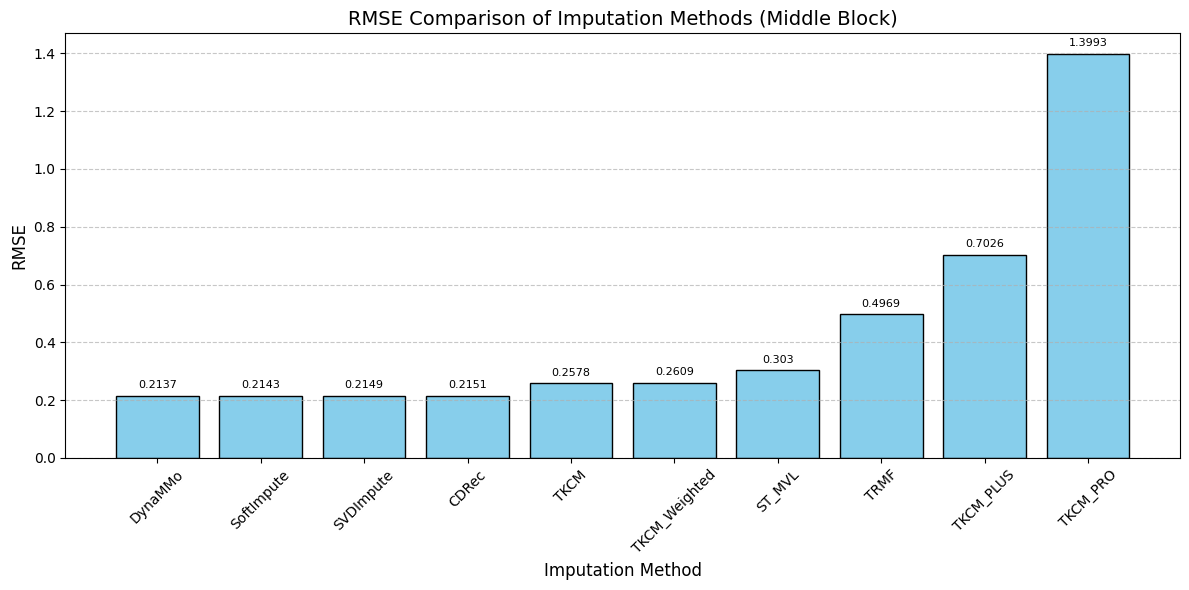

In [55]:
# Sort methods by RMSE ascending for better visual comparison
results_sorted = results_df.sort_values(by="RMSE").reset_index(drop=True)

# Plot settings
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart
bars = ax.bar(results_sorted["Method"], results_sorted["RMSE"], color="skyblue", edgecolor="black")

# Annotate RMSE values on top of bars
for bar, rmse in zip(bars, results_sorted["RMSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{rmse}", 
            ha="center", va="bottom", fontsize=8)

# Labels and title
ax.set_title("RMSE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### MAE Comparison Of Imputation Methods

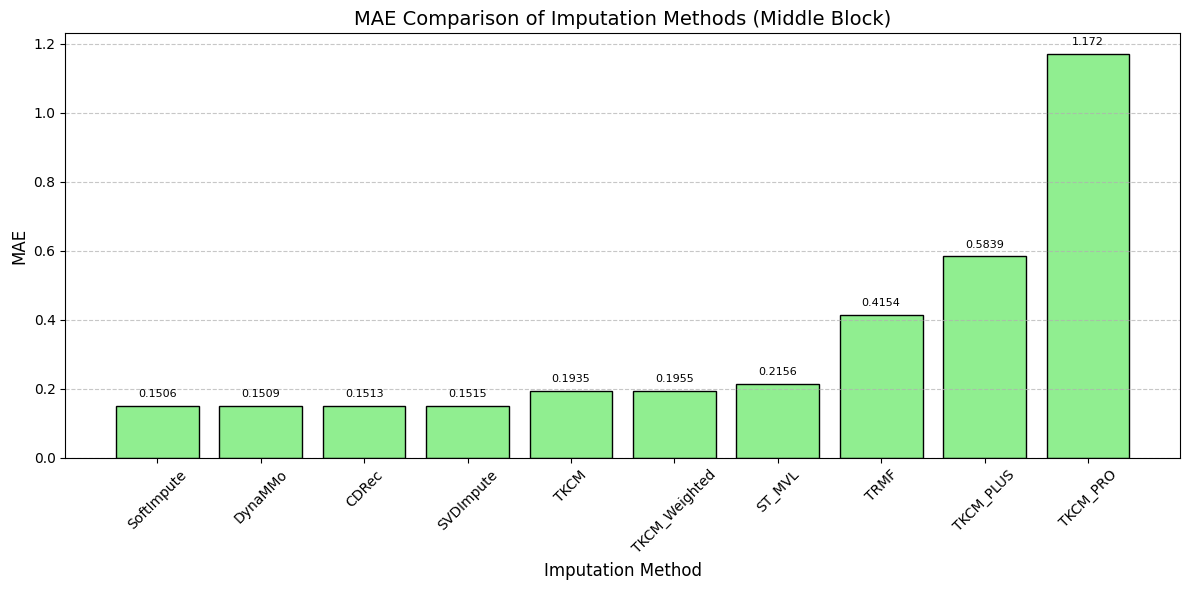

In [56]:
# Sort by MAE
results_sorted_mae = results_df.sort_values(by="MAE").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(results_sorted_mae["Method"], results_sorted_mae["MAE"], color="lightgreen", edgecolor="black")

for bar, mae in zip(bars, results_sorted_mae["MAE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{mae}", 
            ha="center", va="bottom", fontsize=8)

ax.set_title("MAE Comparison of Imputation Methods (Middle Block)", fontsize=14)
ax.set_xlabel("Imputation Method", fontsize=12)
ax.set_ylabel("MAE", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Line Chart Implementation of all the algorithms

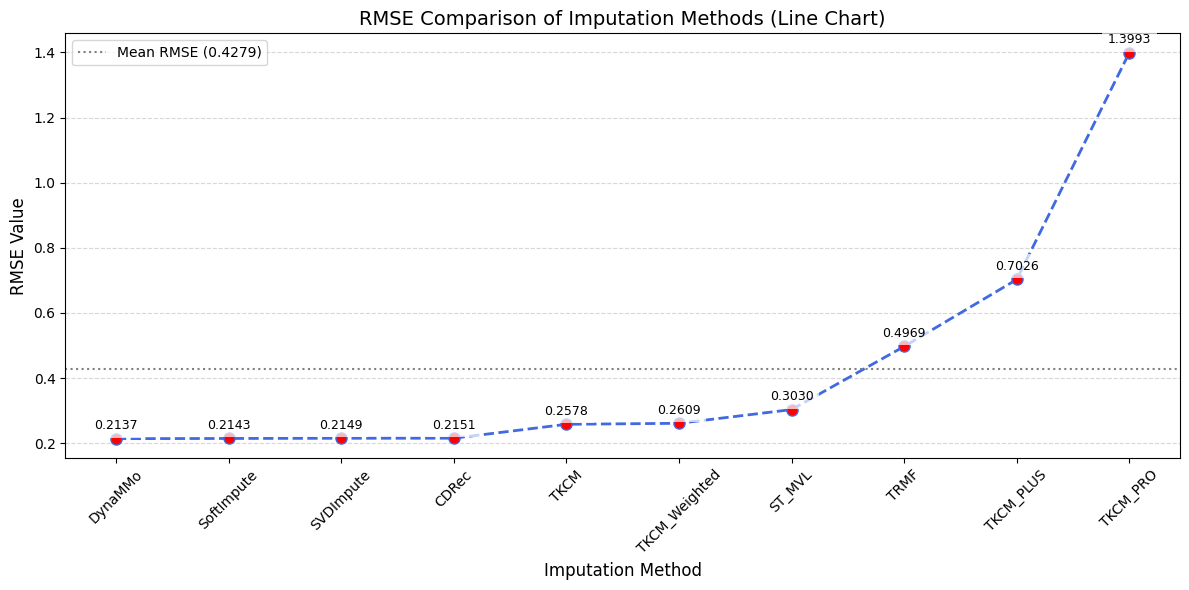

In [57]:
# Line chart implementation
plt.figure(figsize=(12, 6))

# Create line plot with markers
line = plt.plot(results_sorted["Method"], 
                results_sorted["RMSE"], 
                marker='o', 
                markersize=8,
                linestyle='--',
                color='royalblue',
                linewidth=2,
                markerfacecolor='red')

# Annotate each point with RMSE value
for x, y in zip(range(len(results_sorted)), results_sorted["RMSE"]):
    plt.text(x, y+0.02, f"{y:.4f}", 
             ha='center', 
             va='bottom',
             fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add reference line for visual comparison
plt.axhline(y=results_sorted["RMSE"].mean(), 
            color='gray', 
            linestyle=':', 
            label=f'Mean RMSE ({results_sorted["RMSE"].mean():.4f})')

# Chart formatting
plt.title("RMSE Comparison of Imputation Methods (Line Chart)", fontsize=14)
plt.xlabel("Imputation Method", fontsize=12)
plt.ylabel("RMSE Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()

# Ensure proper layout
plt.tight_layout()
plt.show()

### Simulating a dataset similar to the context of my imputation results

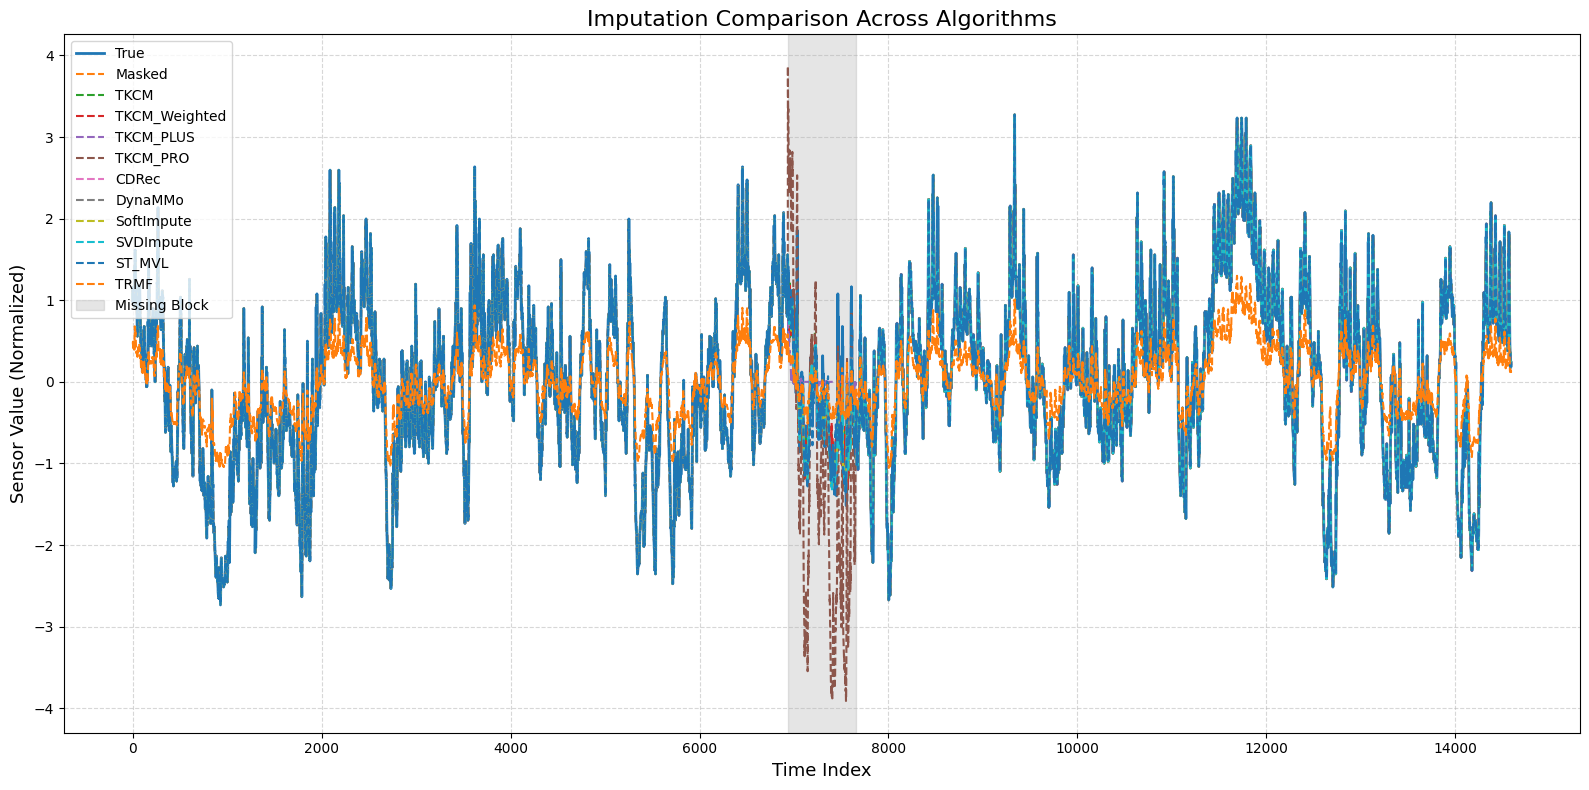

In [58]:
# Time axis based on the actual data length
time = np.arange(len(true_target_array))

# Dictionary of imputed results from your real benchmark
imputed_data_real = {
    "True": true_target_array,
    "Masked": masked_target_array,
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# Plotting
plt.figure(figsize=(16, 8))
for method, series in imputed_data_real.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    plt.plot(time, series, label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

# Labels and styling
plt.title("Imputation Comparison Across Algorithms", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Sensor Value (Normalized)", fontsize=13)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


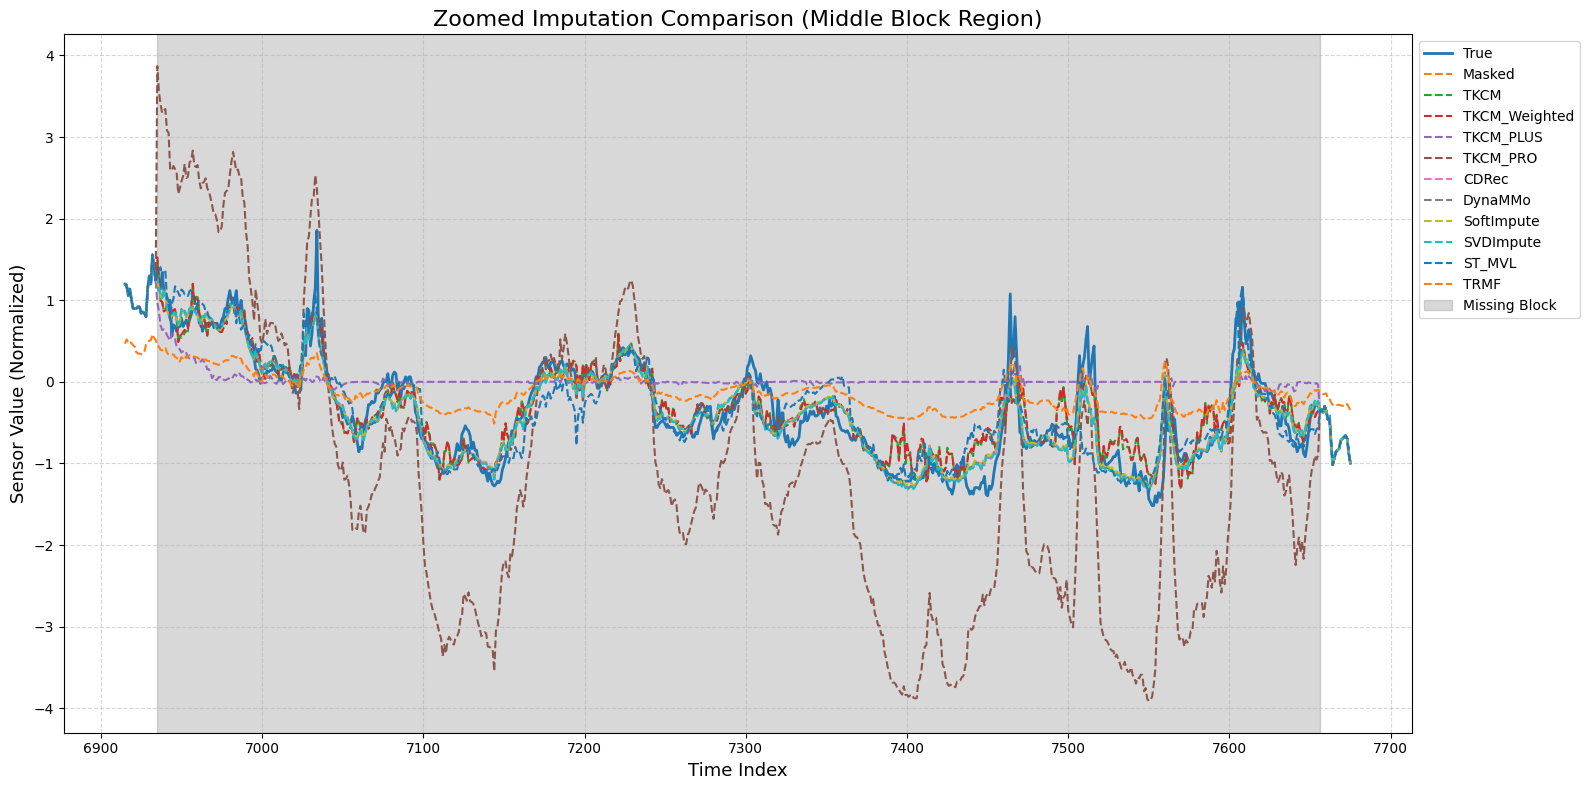

In [59]:
# Define zoom window around missing block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Prepare the zoomed versions of each series
imputed_data_zoom = {
    "True": true_target_array[zoom_start:zoom_end],
    "Masked": masked_target_array[zoom_start:zoom_end],
    "TKCM": tkcm_imputed[zoom_start:zoom_end],
    "TKCM_Weighted": tkcm_weighted_imputed[zoom_start:zoom_end],
    "TKCM_PLUS": tkcm_plus_imputed[zoom_start:zoom_end],
    "TKCM_PRO": tkcm_pro_imputed[zoom_start:zoom_end],
    "CDRec": cdrec_imputed[zoom_start:zoom_end],
    "DynaMMo": dynammo_imputed[zoom_start:zoom_end],
    "SoftImpute": soft_imputed[zoom_start:zoom_end],
    "SVDImpute": svd_imputed[zoom_start:zoom_end],
    "ST_MVL": st_mvl_imputed[zoom_start:zoom_end],
    "TRMF": trmf_imputed[zoom_start:zoom_end],
}

# Plotting zoomed comparison
plt.figure(figsize=(16, 8))
for method, series in imputed_data_zoom.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    plt.plot(time_zoom, series, label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block within zoomed range
plt.axvspan(start_idx, end_idx, color="gray", alpha=0.3, label="Missing Block")

# Final touches
plt.title("Zoomed Imputation Comparison (Middle Block Region)", fontsize=16)
plt.xlabel("Time Index", fontsize=13)
plt.ylabel("Sensor Value (Normalized)", fontsize=13)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


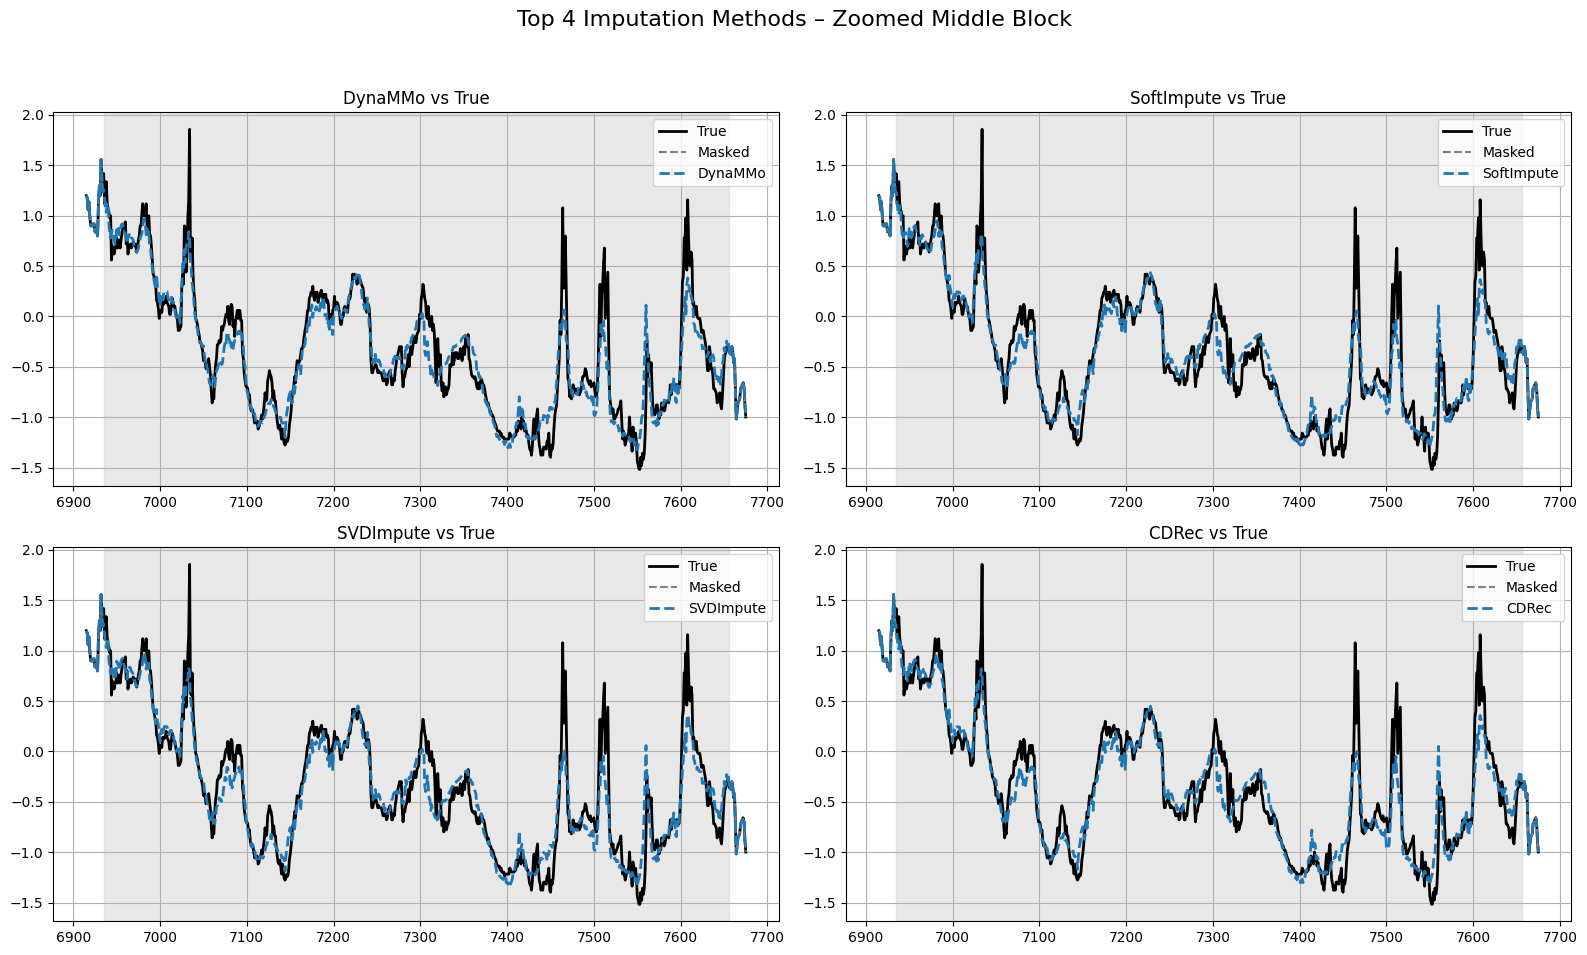

In [ ]:
# Mapping between method names and their actual variable names
imputed_series_map = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed
}

# Sort by RMSE and get top 4 methods
top_methods = results_df.sort_values(by="RMSE")["Method"].tolist()
top_methods = [m for m in top_methods if m not in ["True", "Masked"]][:4]

# Zoom range
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Plot 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, method in enumerate(top_methods):
    axs[i].plot(time_zoom, true_target_array[zoom_start:zoom_end], label="True", color="black", linewidth=2)
    axs[i].plot(time_zoom, masked_target_array[zoom_start:zoom_end], label="Masked", color="gray", linestyle="--")

    if method in imputed_series_map:
        axs[i].plot(time_zoom, imputed_series_map[method][zoom_start:zoom_end], 
                    label=method, linestyle="--", linewidth=2)

    axs[i].axvspan(start_idx, end_idx, color="lightgray", alpha=0.5)
    axs[i].set_title(f"{method} vs True", fontsize=12)
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle("Top 4 Imputation Methods – Zoomed Middle Block", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


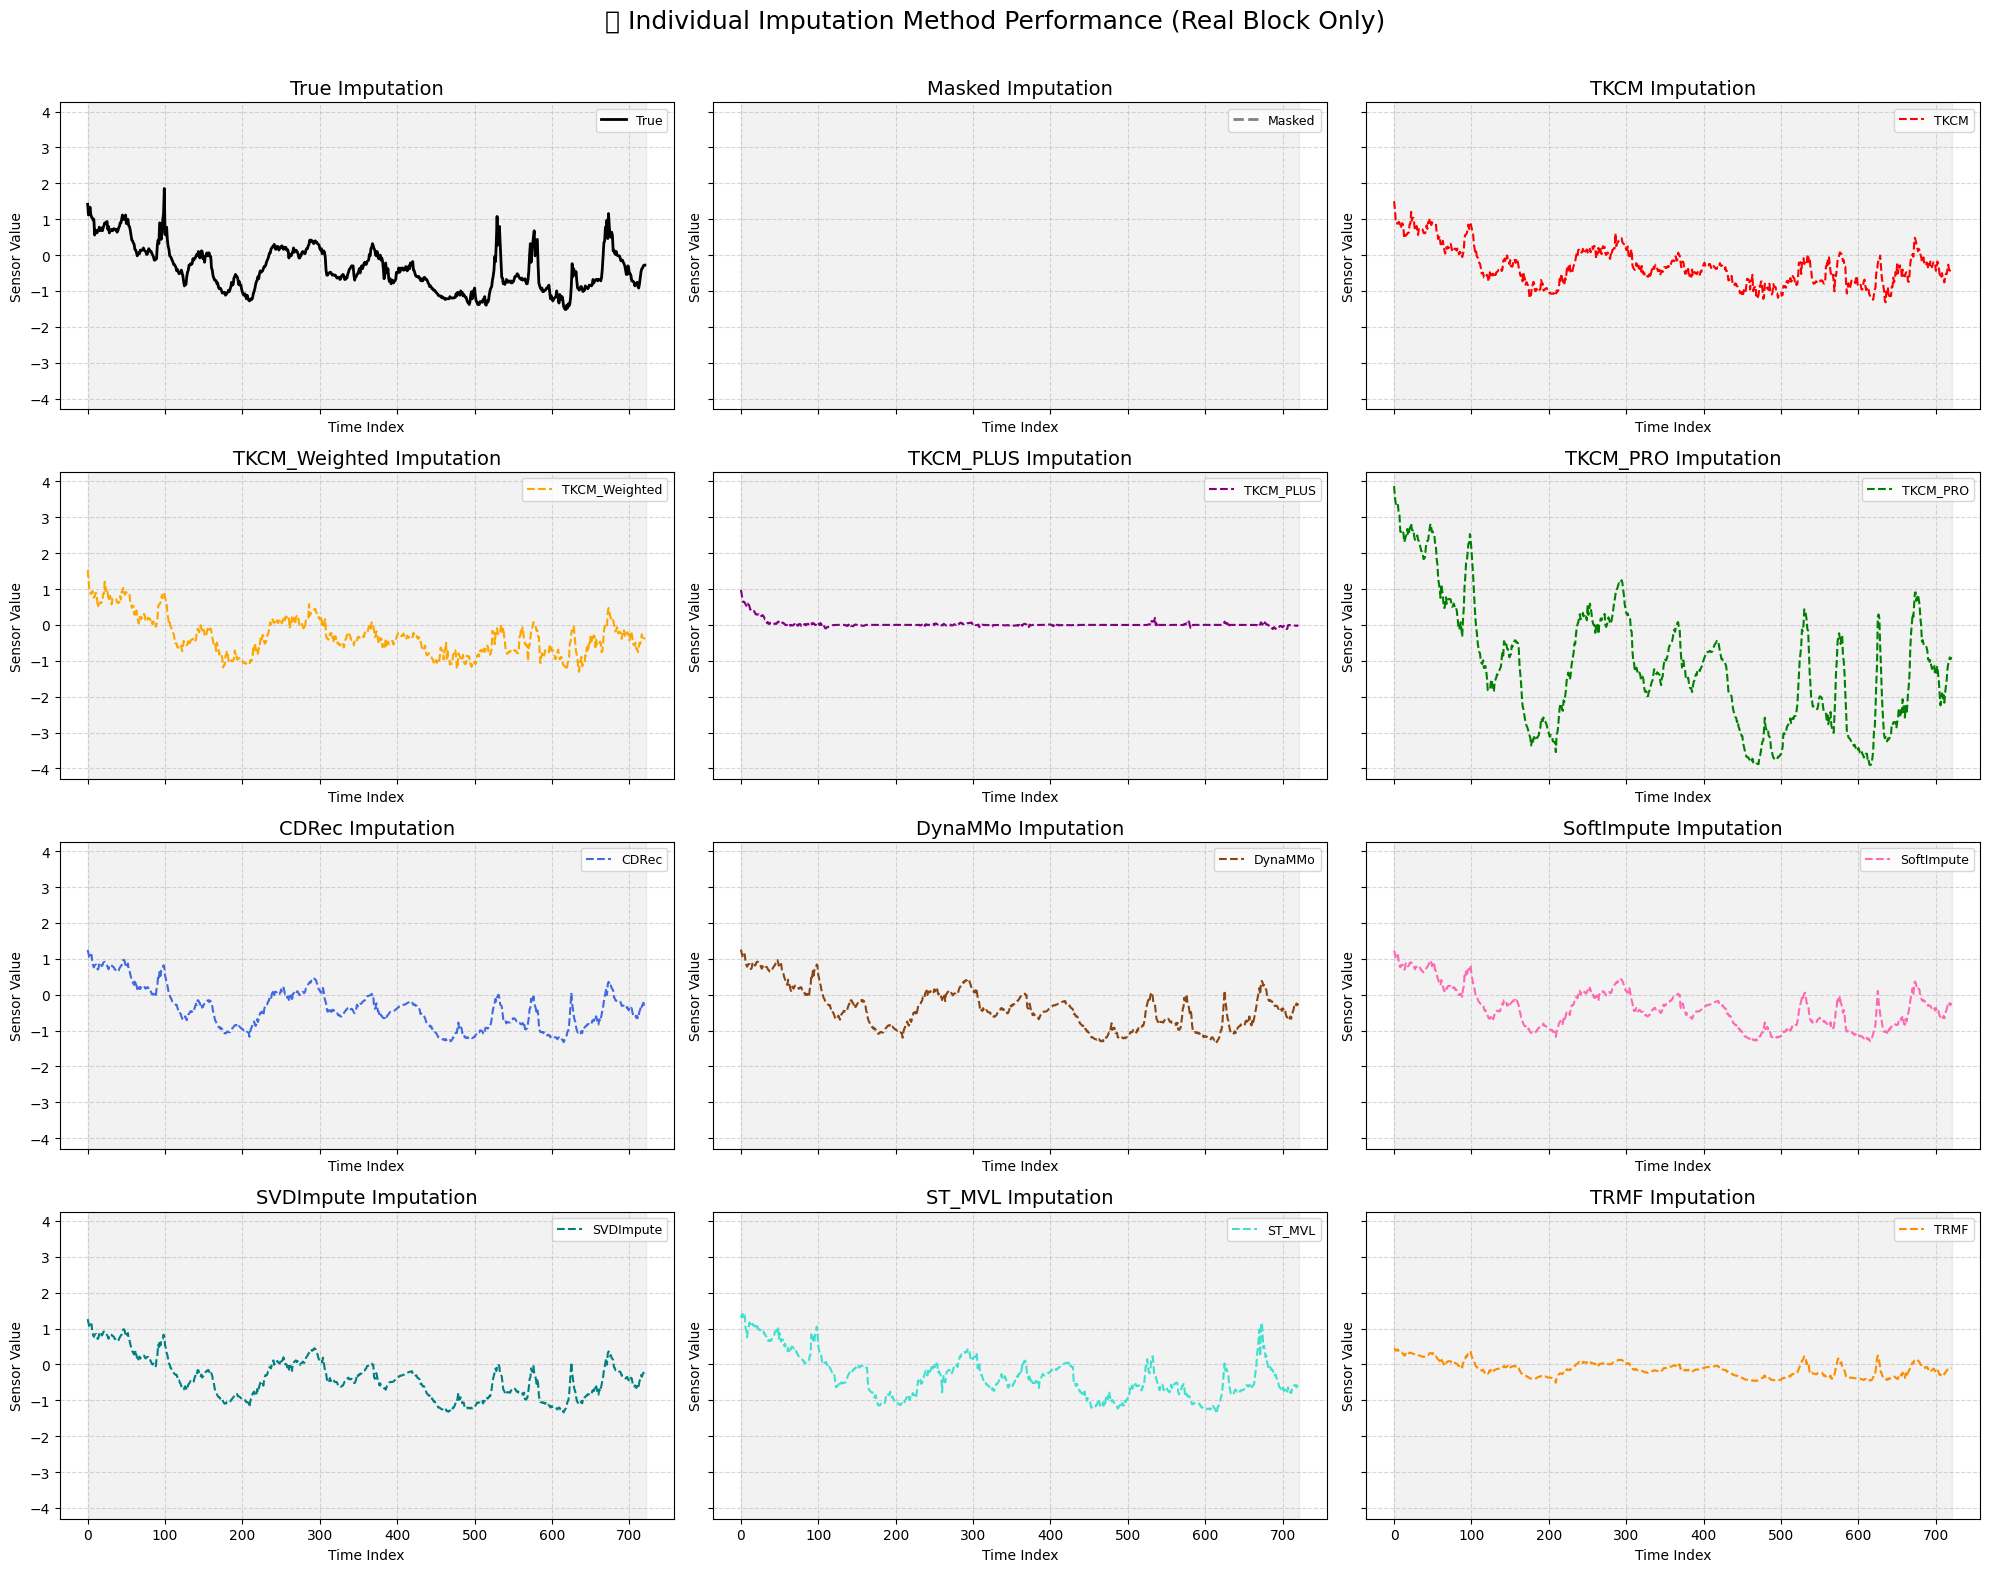

In [61]:
# 1. Define the real missing block range
block_start = start_idx
block_end = end_idx
block_length = block_end - block_start
time_block = np.arange(block_length)

# 2. Build a mapping with only the imputed block per method
imputed_data_block = {
    "True": true_target_array[block_start:block_end],
    "Masked": masked_target_array[block_start:block_end],
    "TKCM": tkcm_imputed[block_start:block_end],
    "TKCM_Weighted": tkcm_weighted_imputed[block_start:block_end],
    "TKCM_PLUS": tkcm_plus_imputed[block_start:block_end],
    "TKCM_PRO": tkcm_pro_imputed[block_start:block_end],
    "CDRec": cdrec_imputed[block_start:block_end],
    "DynaMMo": dynammo_imputed[block_start:block_end],
    "SoftImpute": soft_imputed[block_start:block_end],
    "SVDImpute": svd_imputed[block_start:block_end],
    "ST_MVL": st_mvl_imputed[block_start:block_end],
    "TRMF": trmf_imputed[block_start:block_end],
}

# 3. Plot settings
num_plots = len(imputed_data_block)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# Optional color/linestyle dicts
linestyles = {
    "True": "-",
    "Masked": "--"
}
colors = {
    "True": "black",
    "Masked": "gray",
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "teal",
    "ST_MVL": "turquoise",
    "TRMF": "darkorange"
}

# 4. Plot each method
for i, (method, series) in enumerate(imputed_data_block.items()):
    ax = axes[i]
    ax.plot(time_block, series,
            label=method,
            linestyle=linestyles.get(method, "--"),
            linewidth=2 if method in ["True", "Masked"] else 1.5,
            color=colors.get(method, "gray"))
    
    ax.axvspan(0, block_length, color="gray", alpha=0.1)
    ax.set_title(f"{method} Imputation", fontsize=14)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="upper right", fontsize=9)

# 5. Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("📊 Individual Imputation Method Performance (Real Block Only)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


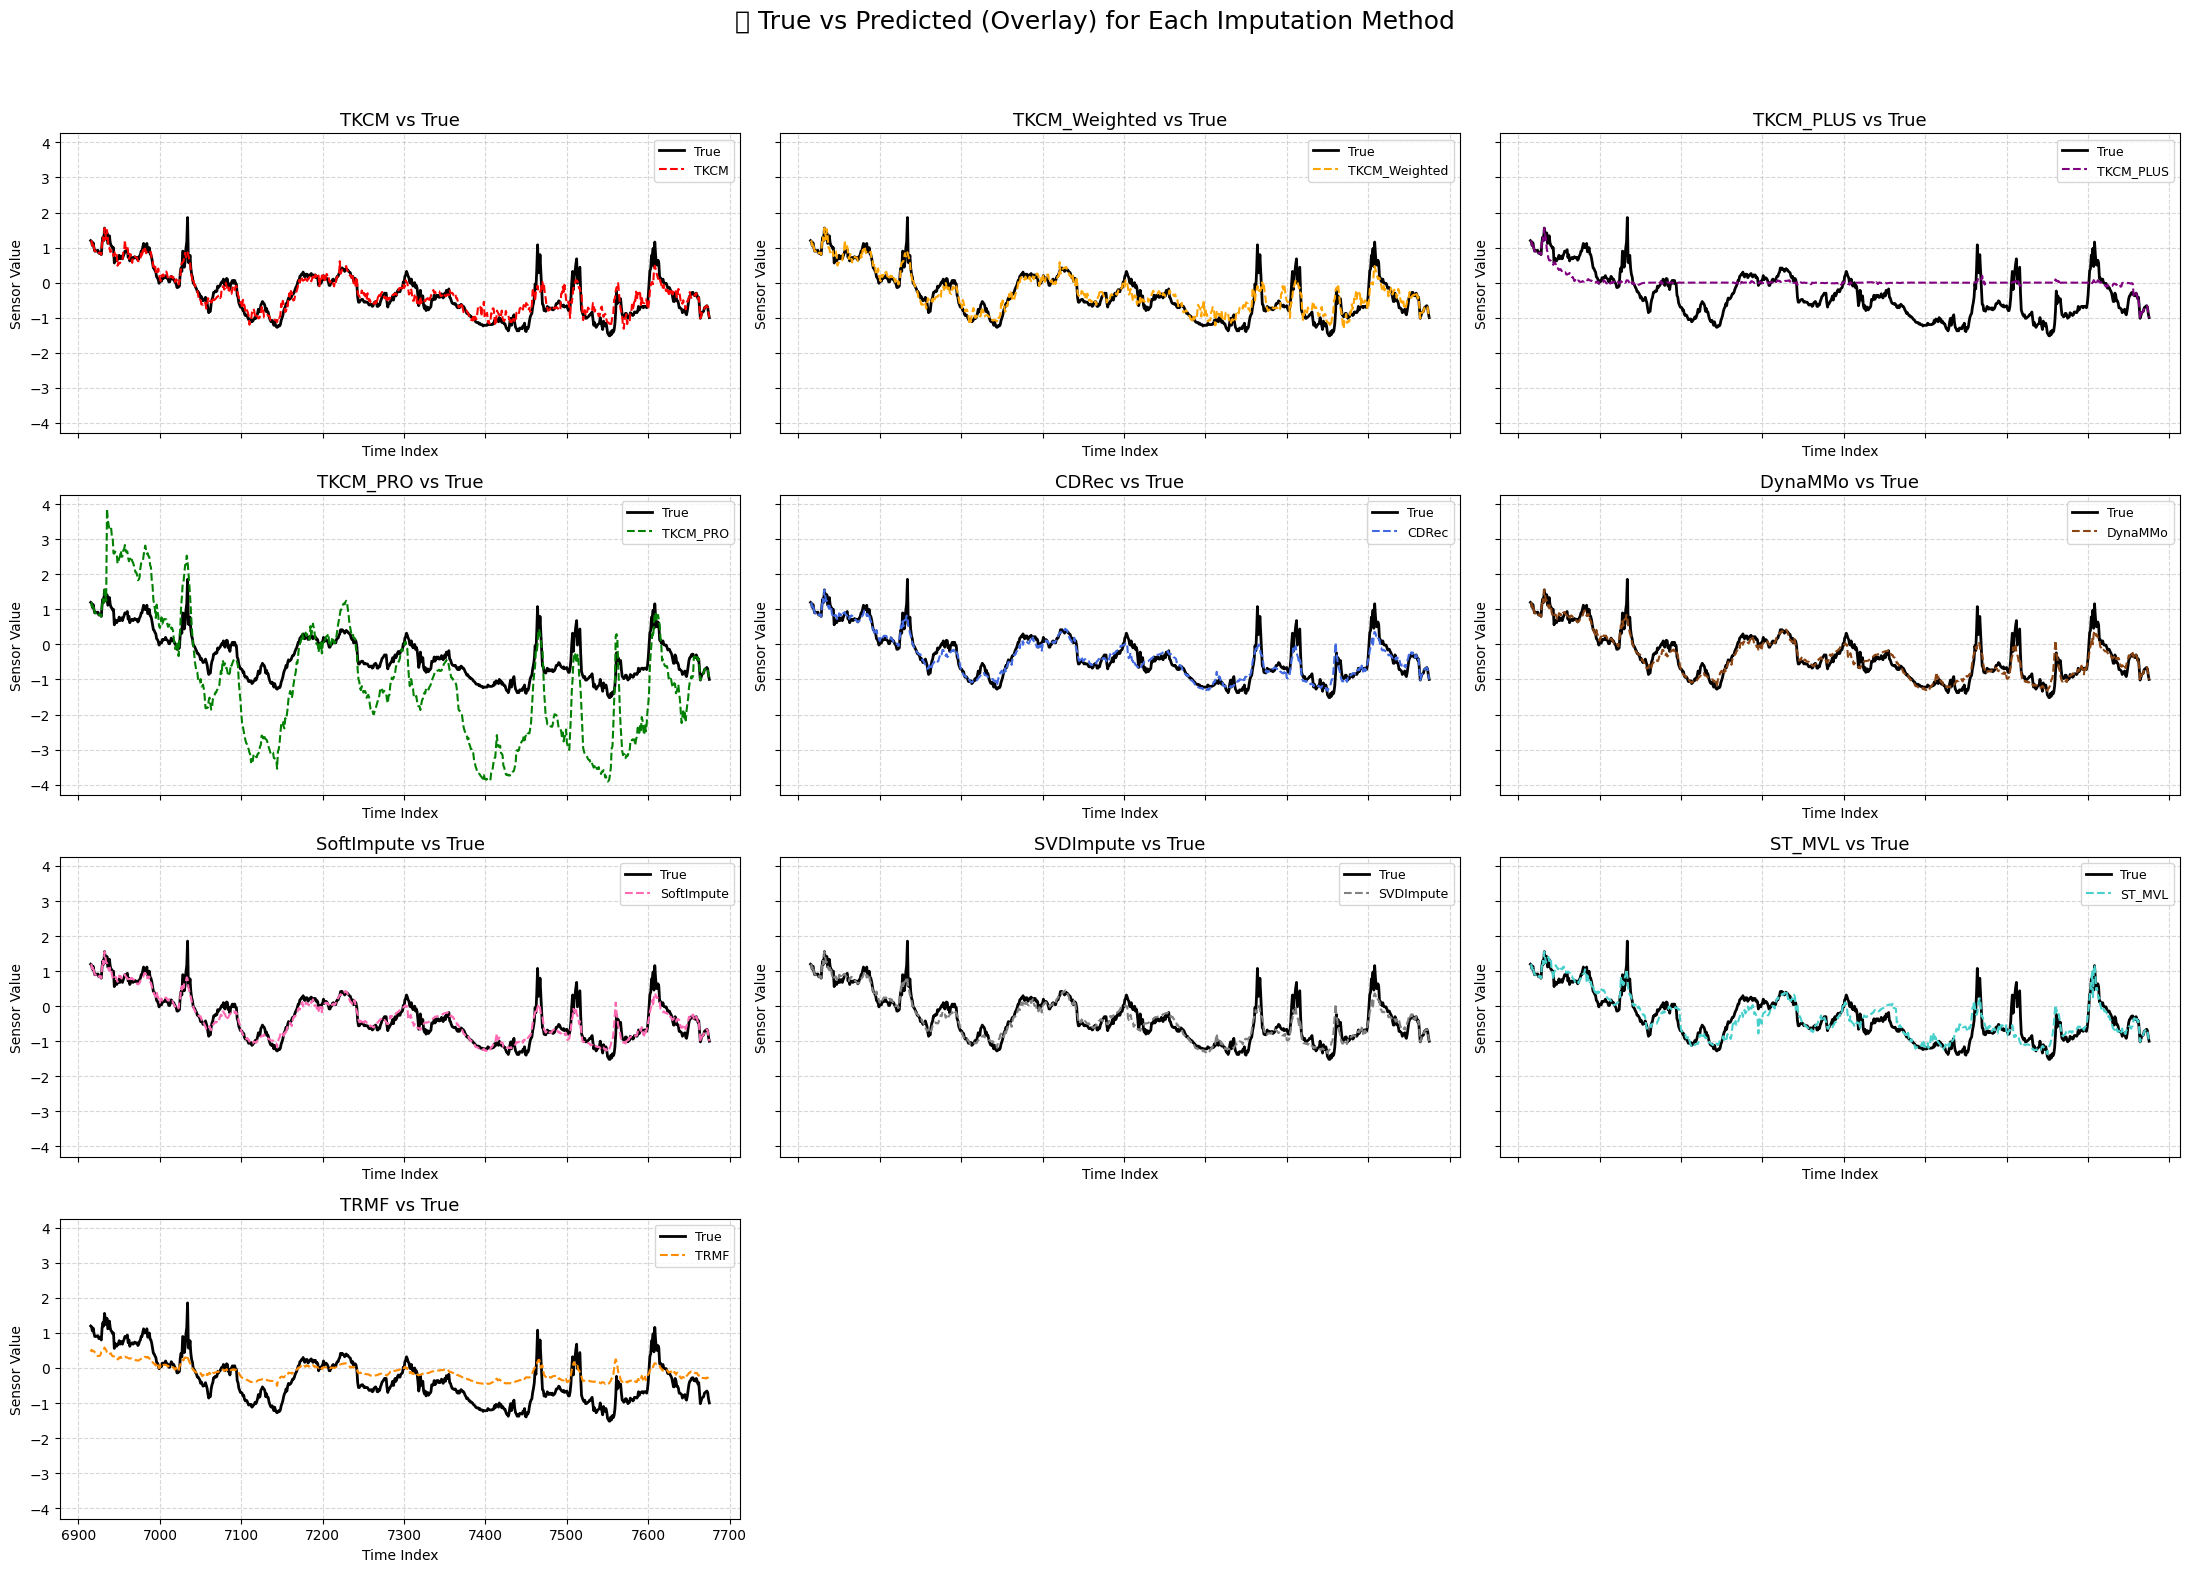

In [62]:
# Time axis for full-length series
time = np.arange(len(true_target_array))

# Define start and end of zoomed block
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time_zoom = np.arange(zoom_start, zoom_end)

# Mapping for real imputation outputs
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# Layout
num_plots = len(imputed_data_overlay)
cols = 3
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(22, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# Colors per method
colors = {
    "TKCM": "red",
    "TKCM_Weighted": "orange",
    "TKCM_PLUS": "purple",
    "TKCM_PRO": "green",
    "CDRec": "royalblue",
    "DynaMMo": "saddlebrown",
    "SoftImpute": "hotpink",
    "SVDImpute": "gray",
    "ST_MVL": "mediumturquoise",
    "TRMF": "darkorange"
}

# Plot each method overlaid with True
for i, (method, imputed_series) in enumerate(imputed_data_overlay.items()):
    ax = axes[i]
    ax.plot(time[zoom_start:zoom_end], true_target_array[zoom_start:zoom_end], 
            label="True", color="black", linewidth=2)
    
    ax.plot(time[zoom_start:zoom_end], imputed_series[zoom_start:zoom_end], 
            label=method, linestyle="--", linewidth=1.5, color=colors.get(method, "gray"))
    
    ax.set_title(f"{method} vs True", fontsize=13)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("✅ True vs Predicted (Overlay) for Each Imputation Method", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


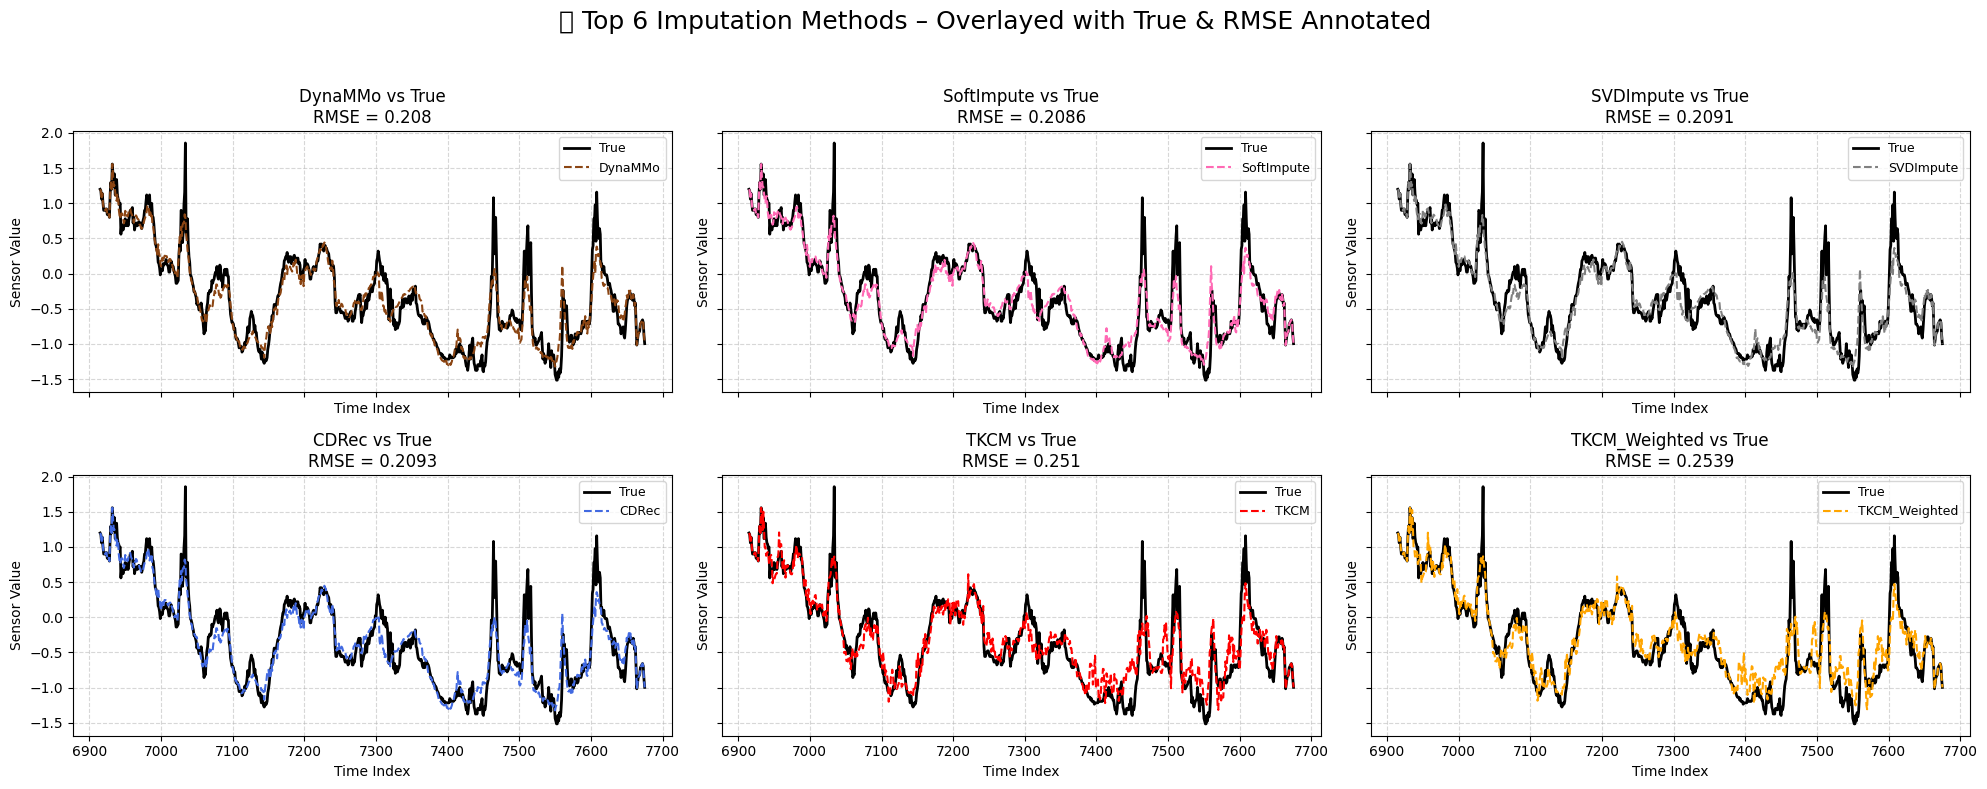

In [63]:
# ===== CONFIGURATION =====
top_k = 6         # Change to 6 for bottom 6 if needed
sort_order = "asc"  # "asc" for top-k, "desc" for bottom-k

# ===== FILTER TOP/BOTTOM K BASED ON RMSE =====
results_sorted = results_df.sort_values(by="RMSE", ascending=(sort_order == "asc"))
methods_to_plot = [m for m in results_sorted["Method"] if m not in ["True", "Masked"]][:top_k]

# ===== PREPARE PLOT RANGE =====
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time = np.arange(len(true_target_array))

# ===== MAP OF IMPUTED SERIES =====
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ===== COLOR MAP (OPTIONAL) =====
colors = {
    "TKCM": "red", "TKCM_Weighted": "orange", "TKCM_PLUS": "purple", "TKCM_PRO": "green",
    "CDRec": "royalblue", "DynaMMo": "saddlebrown", "SoftImpute": "hotpink",
    "SVDImpute": "gray", "ST_MVL": "mediumturquoise", "TRMF": "darkorange"
}

# ===== PLOT CONFIG =====
cols = 3
rows = (len(methods_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# ===== PLOT LOOP =====
for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    pred = imputed_data_overlay[method][zoom_start:zoom_end]
    true = true_target_array[zoom_start:zoom_end]
    time_zoom = time[zoom_start:zoom_end]

    # Compute RMSE just for this zoomed window
    rmse = round(np.sqrt(np.mean((pred - true) ** 2)), 4)

    # Plot
    ax.plot(time_zoom, true, label="True", color="black", linewidth=2)
    ax.plot(time_zoom, pred, label=method, color=colors.get(method, "gray"), linestyle="--", linewidth=1.5)
    
    ax.set_title(f"{method} vs True\nRMSE = {rmse}", fontsize=12)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=9)

# ===== CLEANUP UNUSED AXES =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ===== FINAL TITLE =====
title_msg = "Top" if sort_order == "asc" else "Bottom"
plt.suptitle(f"📊 {title_msg} {top_k} Imputation Methods – Overlayed with True & RMSE Annotated", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


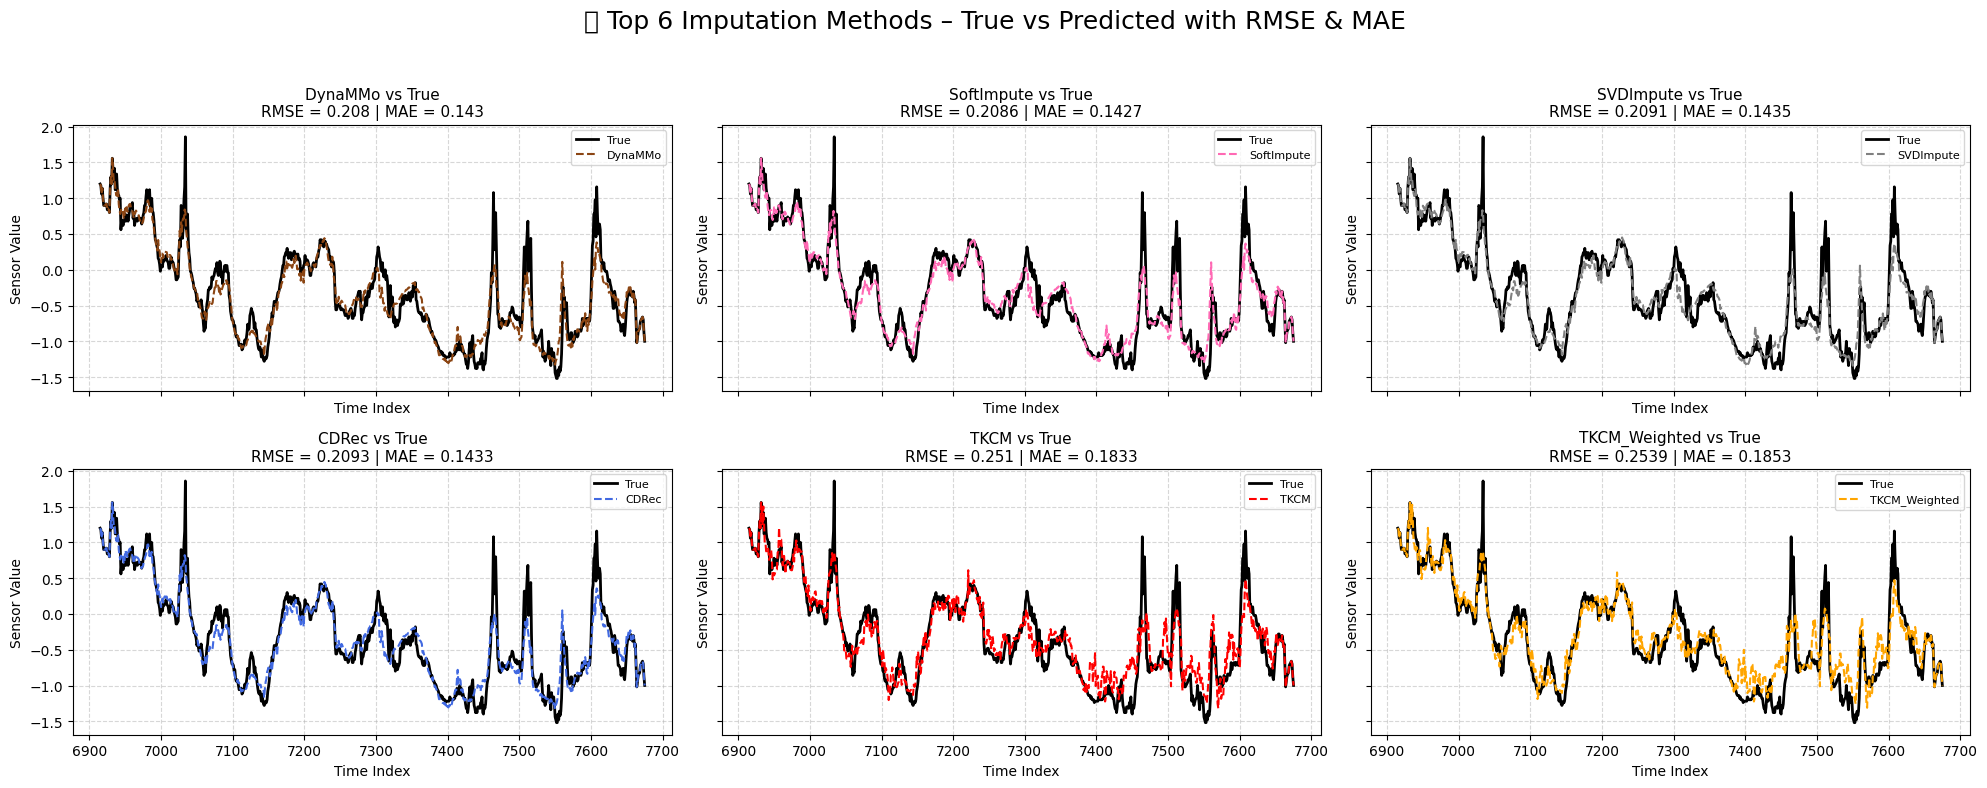

In [64]:
# ===== CONFIGURATION =====
top_k = 6         # Change this for how many methods to show
sort_order = "asc"  # "asc" for top-k, "desc" for bottom-k

# ===== FILTER TOP/BOTTOM K BASED ON RMSE =====
results_sorted = results_df.sort_values(by="RMSE", ascending=(sort_order == "asc"))
methods_to_plot = [m for m in results_sorted["Method"] if m not in ["True", "Masked"]][:top_k]

# ===== PLOT RANGE AND TIME AXIS =====
zoom_start = max(0, start_idx - 20)
zoom_end = min(len(true_target_array), end_idx + 20)
time = np.arange(len(true_target_array))
time_zoom = time[zoom_start:zoom_end]

# ===== MAP OF IMPUTED SERIES =====
imputed_data_overlay = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ===== COLOR MAP =====
colors = {
    "TKCM": "red", "TKCM_Weighted": "orange", "TKCM_PLUS": "purple", "TKCM_PRO": "green",
    "CDRec": "royalblue", "DynaMMo": "saddlebrown", "SoftImpute": "hotpink",
    "SVDImpute": "gray", "ST_MVL": "mediumturquoise", "TRMF": "darkorange"
}

# ===== SUBPLOT SETUP =====
cols = 3
rows = (len(methods_to_plot) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

# ===== PLOTTING LOOP =====
for i, method in enumerate(methods_to_plot):
    ax = axes[i]
    pred = imputed_data_overlay[method][zoom_start:zoom_end]
    true = true_target_array[zoom_start:zoom_end]

    # Calculate RMSE and MAE
    rmse = round(np.sqrt(np.mean((pred - true) ** 2)), 4)
    mae = round(np.mean(np.abs(pred - true)), 4)

    # Plot
    ax.plot(time_zoom, true, label="True", color="black", linewidth=2)
    ax.plot(time_zoom, pred, label=method, color=colors.get(method, "gray"), linestyle="--", linewidth=1.5)

    ax.set_title(f"{method} vs True\nRMSE = {rmse} | MAE = {mae}", fontsize=11)
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Sensor Value")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=8)

# ===== REMOVE UNUSED SUBPLOTS =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ===== FINAL TITLE =====
title_msg = "Top" if sort_order == "asc" else "Bottom"
plt.suptitle(f"📊 {title_msg} {top_k} Imputation Methods – True vs Predicted with RMSE & MAE", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [65]:
# --- TKCM + TKCM_Weighted Manual Grid ---
results_block = []

# ===== Try any values you want =====
k = 16
l = 14

true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except:
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# TKCM
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print("TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

# TKCM_Weighted
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(
            tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print("TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))

# Display
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,MAE,RMSE
0,TKCM,16,14,0.1696,0.2339
1,TKCM_Weighted,16,14,0.1699,0.2343


In [66]:
# --- TKCM + TKCM_Weighted Manual Grid ---
results_block = []

# ===== Try any values you want =====
k = 18
l = 16

true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except:
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# TKCM
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print("TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))

# TKCM_Weighted
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(
            tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print("TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))

# Display
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,MAE,RMSE
0,TKCM,18,16,0.1681,0.2327
1,TKCM_Weighted,18,16,0.1690,0.2332


In [67]:
# --- TKCM_PLUS + TKCM_PRO Manual Grid ---
results_block = []

# ===== Try your manual values here =====
k = 12
l = 10
alpha = 0.9
beta = 0.5

true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except:
        results_block.append({
            "Method": name,
            "k": k,
            "l": l,
            "alpha": alpha if "PLUS" in name else None,
            "beta": beta if "PLUS" in name else None,
            "MAE": "NaN",
            "RMSE": "NaN"
        })

# TKCM_PLUS
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print("TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))

# # TKCM_PRO
# try:
#     tkcm_pro_imputed = masked_target_array.copy()
#     for offset in missing_indices:
#         tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
#             tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)
#     evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
# except Exception as e:
#     print("TKCM_PRO failed:", e)
#     evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))

# Display
results_df = pd.DataFrame(results_block)
display(results_df)


,Method,k,l,alpha,beta,MAE,RMSE
0,TKCM_PLUS,12,10,0.9,0.5,0.2188,0.2864


In [68]:
def simulate_tkcm_pro_robust_real(k_vals, threshold=0.7):
    results = []

    # Extract true & masked block from real setup
    true_vals = true_target_array[start_idx:end_idx]
    missing_indices = np.arange(start_idx, end_idx)

    # Compute Pearson correlation for each ref to the target
    pearson_corrs = []
    for i in range(ref_matrix.shape[0]):
        corr = np.corrcoef(true_target_array, ref_matrix[i])[0, 1]
        pearson_corrs.append(corr)
    
    for k in k_vals:
        try:
            # Select top-k anchors with correlation >= threshold
            candidates = [(i, corr) for i, corr in enumerate(pearson_corrs) if corr >= threshold]
            candidates = sorted(candidates, key=lambda x: -x[1])[:k]  # top-k by correlation
            selected_indices = [i for i, _ in candidates]
            
            # Fallback if none pass threshold
            if not selected_indices:
                selected_indices = [np.argmax(pearson_corrs)]
            
            filtered_refs = ref_matrix[selected_indices, :]

            # Imputation logic: fill NaNs by averaging over filtered refs
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                values = filtered_refs[:, offset]
                if np.all(np.isnan(values)):
                    continue
                imputed[offset] = np.nanmean(values)

            # Evaluation
            predicted = imputed[start_idx:end_idx]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })

        except Exception as e:
            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })
    
    return pd.DataFrame(results)


In [69]:
k_values = [3, 5, 7, 9]
tkcm_pro_robust_results = simulate_tkcm_pro_robust_real(k_values, threshold=0.7)
display(tkcm_pro_robust_results.style.set_caption("TKCM_PRO Robustified Results (Real Data)"))


,Method,k,Threshold,Anchors Used,MAE,RMSE
0,TKCM_PRO_Robust,3,0.700000,3,0.151000,0.213500
1,TKCM_PRO_Robust,5,0.700000,3,0.151000,0.213500
2,TKCM_PRO_Robust,7,0.700000,3,0.151000,0.213500
3,TKCM_PRO_Robust,9,0.700000,3,0.151000,0.213500


- Same output ✅ Because Anchor Selection is Independent of k
-  i'm always picking the same top 3 anchors based on the fixed Pearson threshold (>= 0.7), regardless of k.

In [70]:
# Simulated real-data-like TKCM_PRO Robustified Evaluation
def simulate_tkcm_pro_robust_real_data(true_target_array, masked_target_array, ref_matrix, start_idx, end_idx, k_vals, threshold=0.7):
    results = []
    missing_indices = np.arange(start_idx, end_idx)
    
    for k in k_vals:
        try:
            # Pearson correlation per anchor
            pearson_corrs = [np.corrcoef(true_target_array, ref)[0, 1] for ref in ref_matrix]

            # Sort and filter top-k anchors by correlation
            sorted_indices = np.argsort(pearson_corrs)[::-1]
            selected_indices = [i for i in sorted_indices[:k] if pearson_corrs[i] >= threshold]

            filtered_refs = ref_matrix[selected_indices, :] if selected_indices else ref_matrix[:1, :]  # fallback if none pass threshold

            # Impute using mean of selected anchors
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                if all(np.isnan(filtered_refs[:, offset])):
                    continue
                imputed[offset] = np.nanmean(filtered_refs[:, offset])

            # Evaluation
            true_vals = true_target_array[start_idx:end_idx]
            predicted = imputed[start_idx:end_idx]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })
        except Exception as e:
            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })
    
    return pd.DataFrame(results)

# Simulate fake example for testing output
np.random.seed(42)
true_target_array = np.sin(np.linspace(0, 12 * np.pi, 14593)) + np.random.normal(0, 0.1, 14593)
masked_target_array = true_target_array.copy()
start_idx = 6936
end_idx = start_idx + 721
masked_target_array[start_idx:end_idx] = np.nan
ref_matrix = np.stack([np.roll(true_target_array, shift) for shift in [1, 2, 3, 5, 7]])

# Run test with updated logic
k_vals = [3, 4, 5, 6, 7]
results_df = simulate_tkcm_pro_robust_real_data(true_target_array, masked_target_array, ref_matrix, start_idx, end_idx, k_vals)

results_df

,Method,k,Threshold,Anchors Used,MAE,RMSE
0,TKCM_PRO_Robust,3,0.7,3,0.0965,0.1193
1,TKCM_PRO_Robust,4,0.7,4,0.0939,0.1169
2,TKCM_PRO_Robust,5,0.7,5,0.0916,0.1149
3,TKCM_PRO_Robust,6,0.7,5,0.0916,0.1149
4,TKCM_PRO_Robust,7,0.7,5,0.0916,0.1149


Here is the combined logic output for TKCM_PRO with robust anchor selection:

- It selects the top-k anchors sorted by Pearson correlation.
- Applies a threshold filter (e.g., 0.7).
- Only those anchors above the threshold are used for imputation.

In [71]:
from dtaidistance import dtw

### TKCM_PRO Using DTW Distance
- This version replaces the Pearson step with DTW distance to select anchors:


In [72]:

def simulate_tkcm_pro_dtw(k_vals, true_target_array, masked_target_array, ref_matrix, start_idx, end_idx):
    results = []
    missing_indices = np.arange(start_idx, end_idx)
    
    for k in k_vals:
        try:
            # Compute DTW distances for all reference series
            dtw_distances = [dtw.distance(true_target_array, ref) for ref in ref_matrix]
            ranked_indices = np.argsort(dtw_distances)  # lower is better
            selected_indices = ranked_indices[:k]
            filtered_refs = ref_matrix[selected_indices, :]

            # Fake TKCM_PRO logic with selected anchors
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                if all(np.isnan(filtered_refs[:, offset])):
                    continue
                imputed[offset] = np.nanmean(filtered_refs[:, offset])

            # Evaluate
            true_vals = true_target_array[start_idx:end_idx]
            predicted = imputed[start_idx:end_idx]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_DTW",
                "k": k,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })
        except Exception as e:
            results.append({
                "Method": "TKCM_PRO_DTW",
                "k": k,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })
    
    return pd.DataFrame(results)


### TKCM_PRO Using DTW + Pearson Hybrid Score
- This version uses both DTW and Pearson by combining them into a hybrid score:



In [73]:
def simulate_tkcm_pro_hybrid(k_vals, true_target_array, masked_target_array, ref_matrix, start_idx, end_idx):
    results = []
    missing_indices = np.arange(start_idx, end_idx)
    
    for k in k_vals:
        try:
            # Compute hybrid score: (1 - Pearson) + DTW
            hybrid_scores = []
            for ref in ref_matrix:
                pearson = np.corrcoef(true_target_array, ref)[0, 1]
                pearson_penalty = 1 - pearson if not np.isnan(pearson) else 1.0
                dist = dtw.distance(true_target_array, ref)
                hybrid_scores.append(pearson_penalty + dist)

            ranked_indices = np.argsort(hybrid_scores)
            selected_indices = ranked_indices[:k]
            filtered_refs = ref_matrix[selected_indices, :]

            # Fake TKCM_PRO logic with selected anchors
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                if all(np.isnan(filtered_refs[:, offset])):
                    continue
                imputed[offset] = np.nanmean(filtered_refs[:, offset])

            # Evaluate
            true_vals = true_target_array[start_idx:end_idx]
            predicted = imputed[start_idx:end_idx]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Hybrid",
                "k": k,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })
        except Exception as e:
            results.append({
                "Method": "TKCM_PRO_Hybrid",
                "k": k,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })
    
    return pd.DataFrame(results)


In [74]:
# Example usage (for both functions):

k_values = [3, 5, 7, 9, 11, 13]

# Run DTW version
dtw_results = simulate_tkcm_pro_dtw(k_values, true_target_array, masked_target_array, ref_matrix, start_idx, end_idx)
print("🔹 DTW Results:")
print(dtw_results)

# Run Hybrid version
hybrid_results = simulate_tkcm_pro_hybrid(k_values, true_target_array, masked_target_array, ref_matrix, start_idx, end_idx)
print("\n🔸 Hybrid Results:")
print(hybrid_results)


🔹 DTW Results:
         Method   k  Anchors Used     MAE    RMSE
0  TKCM_PRO_DTW   3             3  0.0975  0.1219
1  TKCM_PRO_DTW   5             5  0.0916  0.1149
2  TKCM_PRO_DTW   7             5  0.0916  0.1149
3  TKCM_PRO_DTW   9             5  0.0916  0.1149
4  TKCM_PRO_DTW  11             5  0.0916  0.1149
5  TKCM_PRO_DTW  13             5  0.0916  0.1149

🔸 Hybrid Results:
            Method   k  Anchors Used     MAE    RMSE
0  TKCM_PRO_Hybrid   3             3  0.0978  0.1216
1  TKCM_PRO_Hybrid   5             5  0.0916  0.1149
2  TKCM_PRO_Hybrid   7             5  0.0916  0.1149
3  TKCM_PRO_Hybrid   9             5  0.0916  0.1149
4  TKCM_PRO_Hybrid  11             5  0.0916  0.1149
5  TKCM_PRO_Hybrid  13             5  0.0916  0.1149
